<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Intrinsic Validation 2 - BSM Extension: NSI
---
This notebook contains the physical propagation scenarios for the NSI extension. The Standard-Model limit, solar propagation, Earth propagation, solar-to-detector propagation and atmospheric propagation are kept here. Numerical convergence, perturbative controls, and the `RuntimeContext` are specified explicitly by the configuration and tolerances below.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Standard-Model-Limit) | **Standard Model Limit** |
| [4](#4.-Solar-Propagation) | **Solar Propagation** |
| [5](#5.-Pure-Flavour-States-Through-Earth) | **Pure Flavour States Through Earth** |
| [6](#6.-Solar-Neutrinos-to-the-Detector) | **Solar Neutrinos to the Detector** |
| [7](#7.-Atmospheric-Propagation) | **Atmospheric Propagation** |
| [8](#8.-Summary) | **Summary** |


## 0. Theoretical Framework
---




### 0.1 Non-Standard Interactions

Propagation NSI parameterize effective neutral-current interactions that modify coherent forward neutrino scattering in matter [1]. For three flavours, TPeanuts writes the flavour-basis Hamiltonian as

$$
H_f(x)=H_{\rm vac}+V_{\rm CC}(x)\left[P_e+\epsilon\right],
\qquad
P_e=\operatorname{diag}(1,0,0),
\qquad
V_{\rm CC}(x)=\sqrt{2}G_F n_e(x),
$$

where the effective dimensionless NSI matrix is Hermitian,

$$
\epsilon=
\begin{pmatrix}
\epsilon_{ee} & \epsilon_{e\mu} & \epsilon_{e\tau}\\
\epsilon_{e\mu}^{*} & \epsilon_{\mu\mu} & \epsilon_{\mu\tau}\\
\epsilon_{e\tau}^{*} & \epsilon_{\mu\tau}^{*} & \epsilon_{\tau\tau}
\end{pmatrix}.
$$

The diagonal entries are real and the off-diagonal entries may be complex. Oscillations are insensitive to a contribution proportional to the identity, so only differences between diagonal entries are observable; TPeanuts uses $\epsilon_{\mu\mu}=0$ as a convenient convention. For antineutrinos the vacuum mixing factors are complex-conjugated and the complete matter term changes sign and is conjugated. The Standard-Model limit is $\epsilon=0$.

The benchmark `nsi_globalfit_esteban2018` is inspired by the global propagation-NSI analysis of Esteban *et al.* [2]. Its values define an illustrative multi-parameter stress test, not a published fit point or an allowed-region claim, because the interpretation depends on parameter correlations, matter composition and fermion conventions.


### 0.2 NSI Support in TPeanuts

The table summarizes the NSI propagation paths exercised by this notebook. **Full support** means that the complete Hermitian NSI matter matrix is passed through the corresponding Hamiltonian and propagation method.

| Method | Vacuum | Solar | Earth | Atmosphere |
|---|---|---|---|---|
| Numerical | Full support | Full support | Full support | Full support |
| Perturbative / adiabatic | Not implemented | `adiabatic_exact` (LZ not supported) | Full support | Full support |

In vacuum the NSI matter term vanishes, so ordinary numerical vacuum propagation remains physically well defined; there is no separate perturbative NSI vacuum implementation. In the Sun, NSI requires `adiabatic_exact`, which diagonalizes the complete local Hamiltonian. The effective-angle approximation and its Landau-Zener correction are restricted to the Standard Model.


### 0.3 Validation observables

The numerical result is the reference and the perturbative result is tested. We report

$$
|\Delta P|=|P_{\rm tested}-P_{\rm reference}|,
\qquad
\frac{|\Delta P|}{|P_{\rm reference}|},
$$

with the relative error evaluated only where $|P_{\rm reference}|\geq10^{-5}$. Smaller reference probabilities are excluded from relative summaries because ratios are unstable near a probability zero, while normalization is checked independently.


### 0.4 Common simulation configuration

| Medium/Module | Attribute | Value |
|---|---|---|
| Core | Physics model | Three-flavour NSI extension |
| Core | Vacuum oscillation preset / ordering | `_SM_NUFIT52_NO` / normal ordering [3] |
| Core | NSI preset | `nsi_globalfit_esteban2018` [2] |
| Core | Legacy precision | `False` |
| Solar | Evolution methods / Landau-Zener | `numerical`, `adiabatic_exact` / unsupported for NSI |
| Solar | Density / spectrum provider | `zenodo` / `legacy` |
| Earth | Perturbative / density model | `even_power` / PREM provider |
| Earth | Numerical method | Midpoint, 400 steps in Sections 3-7 |
| Earth | Detector depth / reunitarize | $1000\,\mathrm{m}$ / `False` in basic cases |
| Atmosphere | Density model | Exponential, matter enabled |
| Atmosphere | Perturbative / numerical | 6 cubic segments / 600 midpoint steps |
| Config | Basic energy and angular grids | 90 points per axis |
| Config | Device / dtype | Runtime-resolved values printed below |
| Config | Relative-error threshold | $10^{-5}$ |

**References**

- [1] Grossman, Y. (1995). Non-standard neutrino interactions and neutrino oscillation experiments. *Phys. Lett. B* **359**, 141-147, [arXiv:hep-ph/9507344](https://arxiv.org/abs/hep-ph/9507344).
- [2] Esteban, I., Gonzalez-Garcia, M. C., Maltoni, M., Martinez-Soler, I., & Salvado, J. (2018). Updated constraints on non-standard interactions from global analysis of oscillation data. *JHEP* **08**, 180, [arXiv:1805.04530](https://arxiv.org/abs/1805.04530).
- [3] Esteban, I. *et al.* (2020). The fate of hints: updated global analysis of three-flavor neutrino oscillations. *JHEP* **09**, 178, [arXiv:2007.14792](https://arxiv.org/abs/2007.14792); NuFIT 5.2 release (2022).


## 1. Libraries




In [1]:
from __future__ import annotations
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (ABSOLUTE_THRESHOLD, FLAVOUR_LABELS, save_and_show, to_numpy, validation_metrics, validation_heatmap, validation_comparison_grid, validation_summary_plot)
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.medium.solar.profile import SolarMediumProfile
from tpeanuts.source.solar import SolarNeutrinoSource
from tpeanuts.medium.solar.probability import solar_probability_mass
from tpeanuts.medium.atmosphere.profile import AtmosphereParameters
from tpeanuts.medium.atmosphere.evolutor import atmosphere_evolutor
from tpeanuts.medium.atmosphere.probability import atmosphere_probability_transition
from tpeanuts.util.context import RuntimeContext


## 2. Paths and Configuration




### 2.1 Paths

`load_notebook_config()` resolves the package directory and applies the common plotting, Torch and NumPy configuration. Following the notebook-relative convention, generated figures and tables are saved under `validation/intrinsic/`.

**Expected results:**<br>
 - The package and output directories exist.
 - The runtime device and dtype match the shared notebook configuration.


In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('validation', 'intrinsic')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {context.device}   dtype: {context.dtype}')


Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\validation\intrinsic
Device      : cuda:0   dtype: torch.float64


### 2.2 Configuration

The runtime-resolved configuration below is the single source of truth for all calculations. It combines the NuFIT 5.2 normal-ordering vacuum parameters with the `nsi_globalfit_esteban2018` propagation-NSI benchmark, PREM-derived Earth inputs, the default solar providers, an exponential atmosphere and the common numerical grids described in Section 0.4.

**Expected results:**<br>
- All profiles and the NSI matrix load successfully.
- The table reports the requested presets, device and dtype,
- Every probability tensor uses the same runtime context.


In [3]:
CDTYPE = torch.complex128 if context.dtype == torch.float64 else torch.complex64
OSCILLATION_PRESET = '_SM_NUFIT52_NO'
NSI_PRESET = 'nsi_globalfit_esteban2018'
oscillation = PropagationConfig.oscillation_parameters_from_preset(OSCILLATION_PRESET, context=context, antinu=False, NSI_extension=NSI_PRESET)
earth = EarthProfile(params=EarthParameters(density_provider='prem', profile_perturbative_name='even_power', profile_perturbative_kwargs={'density_file': str(config.earth_density_file), 'tabulated_density': False}), context=context)
solar_medium = SolarMediumProfile.default(context=context)
solar_source = SolarNeutrinoSource.default(context=context)
atmosphere = AtmosphereParameters(atmosphere_density_source='exponential', nsteps=600, matter=True, perturbative_segments=6, perturbative_degree=3)
DEPTH_M, N_EARTH_STEPS = 1000.0, 400
LEGACY_PRECISION = False
REFERENCE_LABEL, TESTED_LABEL = 'numerical', 'perturbative'
BASIS = torch.eye(3, device=context.device, dtype=CDTYPE)
configuration_rows = [('Core','Physics model','NSI (three flavours)'),('Core','Vacuum oscillation preset',oscillation.preset_name),('Core','NSI preset',NSI_PRESET),('Core','Ordering',oscillation.ordering),('Core','Legacy precision',LEGACY_PRECISION),('Solar','Evolution methods','numerical / adiabatic_exact'),('Solar','Landau-Zener','unsupported for NSI'),('Solar','Density provider','zenodo'),('Solar','Spectrum provider','legacy'),('Earth','Perturbative model',earth.params.profile_perturbative_name),('Earth','Density provider',earth.params.density_provider),('Earth','Numerical steps',N_EARTH_STEPS),('Earth','Detector depth [m]',DEPTH_M),('Earth','Reunitarize basic cases',False),('Atmosphere','Density model',atmosphere.atmosphere_density_source),('Atmosphere','Perturbative fit',f'{atmosphere.perturbative_segments} x degree {atmosphere.perturbative_degree}'),('Atmosphere','Numerical steps',atmosphere.nsteps),('Config','Grid points per basic axis',90),('Config','Device',str(context.device)),('Config','Real dtype',str(context.dtype)),('Config','Relative-error threshold',ABSOLUTE_THRESHOLD)]
display(pd.DataFrame(configuration_rows, columns=['Medium/Module','Attribute','Value']))


,Medium/Module,Attribute,Value
0,Core,Physics model,NSI (three flavours)
1,Core,Vacuum oscillation preset,_SM_NUFIT52_NO
2,Core,NSI preset,nsi_globalfit_esteban2018
3,Core,Ordering,NO
4,Core,Legacy precision,False
5,Solar,Evolution methods,numerical / adiabatic_exact
6,Solar,Landau-Zener,unsupported for NSI
7,Solar,Density provider,zenodo
8,Solar,Spectrum provider,legacy
9,Earth,Perturbative model,even_power


### 2.3 Local Helpers

The reusable validation helpers compute absolute, thresholded-relative and normalization errors, and draw the common heatmaps and probability/error grids. Every physical scenario is self-contained after Sections 1 and 2 and writes its figures into `OUTPUT_DIR`.


In [4]:
summaries = []
ABSOLUTE_THRESHOLD = 1e-3
def record_metrics(case, reference, tested):
    row, absolute, relative = validation_metrics(case, reference, tested, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, absolute_threshold=ABSOLUTE_THRESHOLD)
    summaries.append(row)
    display(pd.DataFrame([row]).set_index('case').style.format({c: '{:.3e}' for c, value in row.items() if isinstance(value, float)}))
    return absolute, relative

def atmosphere_detector_grid(method):
    S_atm, _ = atmosphere_evolutor(oscillation, E_det[:,None], 25.0, theta_det[None,:], DEPTH_M/1000.0, atmosphere=atmosphere, context=context, method=method, legacy_precision=LEGACY_PRECISION)
    angle_results = []
    for i_theta, theta in enumerate(theta_det):
        eta = torch.pi - torch.deg2rad(theta)
        states = []
        for state in BASIS:
            surface_state = torch.matmul(S_atm[:,i_theta], state)
            states.append(earth_probability_state(surface_state, earth, oscillation, E_det[:,None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_det.numel(),3))
        angle_results.append(torch.stack(states))
    return torch.stack(angle_results, dim=2)

def solar_detector_grid(method):
    return torch.stack([earth_probability_state(solar_weights, earth, oscillation, E_solar[:,None], eta, DEPTH_M, method=method, massbasis=True, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_solar.numel(),3) for eta in eta_solar], dim=1)

def earth_flavour_grid(method):
    per_state = []
    for state in BASIS:
        per_eta = [earth_probability_state(state, earth, oscillation, E_earth[:, None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_earth.numel(), 3) for eta in eta_earth]
        per_state.append(torch.stack(per_eta, dim=1))
    return torch.stack(per_state)

def solar_earth_sm_limit_grid(oscillation_parameters, mass_weights):
    return torch.stack([earth_probability_state(mass_weights, earth, oscillation_parameters, E_sm_limit[:,None], eta, DEPTH_M, method='analytical', massbasis=True, nsteps=N_EARTH_STEPS, context=context, reunitarize=False, legacy_precision=LEGACY_PRECISION).reshape(E_sm_limit.numel(),3) for eta in eta_sm_limit], dim=1)


## 3. Standard Model Limit

This test verifies the $\epsilon_{\alpha\beta}\to0$ limit across the complete solar-Earth chain. The reference uses ordinary three-flavour Standard-Model oscillation parameters with no NSI object. The tested branch attaches the NSI preset `sm_no_nsi`, whose complete $\epsilon$ matrix is zero. Both branches use `adiabatic_exact` for $^8$B production and the perturbative Earth method with `reunitarize=False`; therefore, the only implementation-level difference is how the zero NSI contribution enters the Hamiltonian.

For each branch, the solar calculation produces incoherent mass weights

$$P_i^\odot(E)=\int dr\,f_{8B}(r)\left|U^m_{ei}(r,E)\right|^2,$$

which are then propagated through Earth and projected onto detected flavours. The comparison spans solar energy and nadir angle.

**Expected results:**<br>
 - The Standard Model and `sm_no_nsi` probabilities should agree to floating-point precision over the entire grid, remain normalized and show the same Earth-regeneration pattern.
 - Any discrepancy larger than round-off would indicate an inconsistency in the NSI Hamiltonian's zero-coupling limit.


,max_abs,mean_abs,max_rel,mean_rel,normalization_Standard Model,normalization_NSI sm_no_nsi,relative_points,absolute_threshold
case,,,,,,,,
solar-Earth SM limit,1.331e-13,6.321e-15,2.582e-13,1.894e-14,5.213e-04,5.213e-04,2.430e+04,1.000e-03


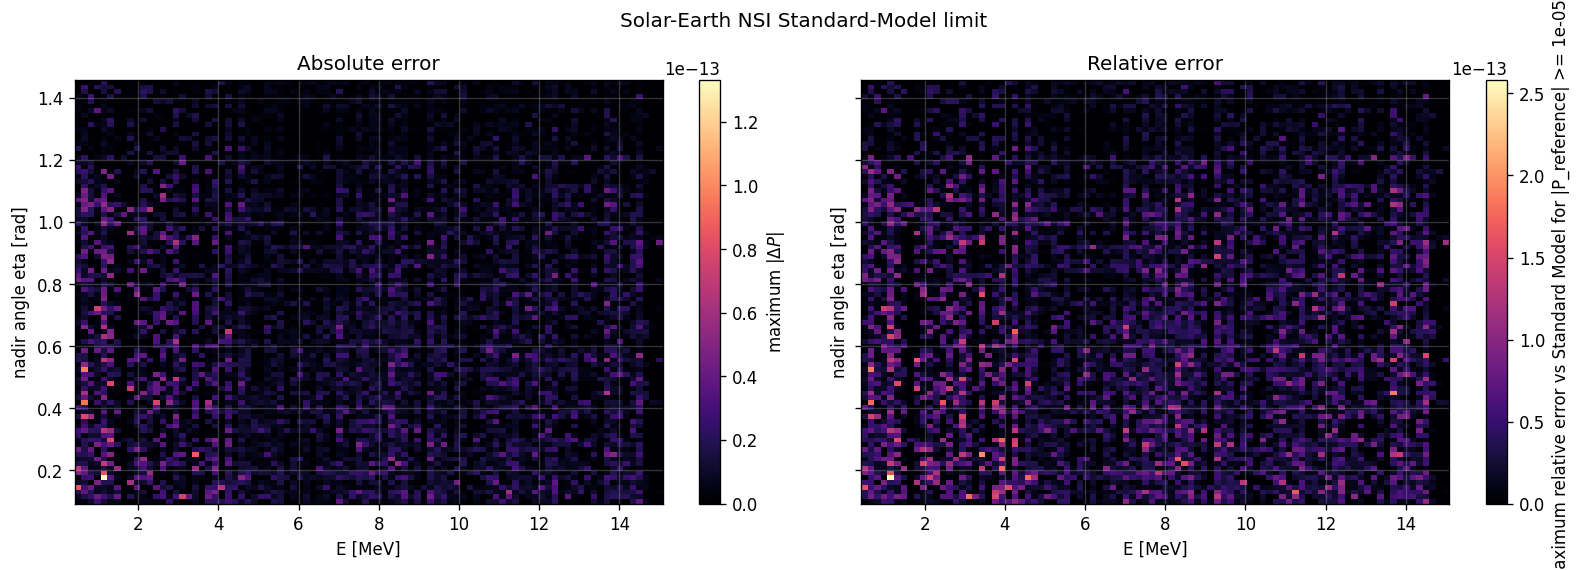

v:\output\validation\intrinsic\intrinsic2_nsi_fig3_sm_limit.png


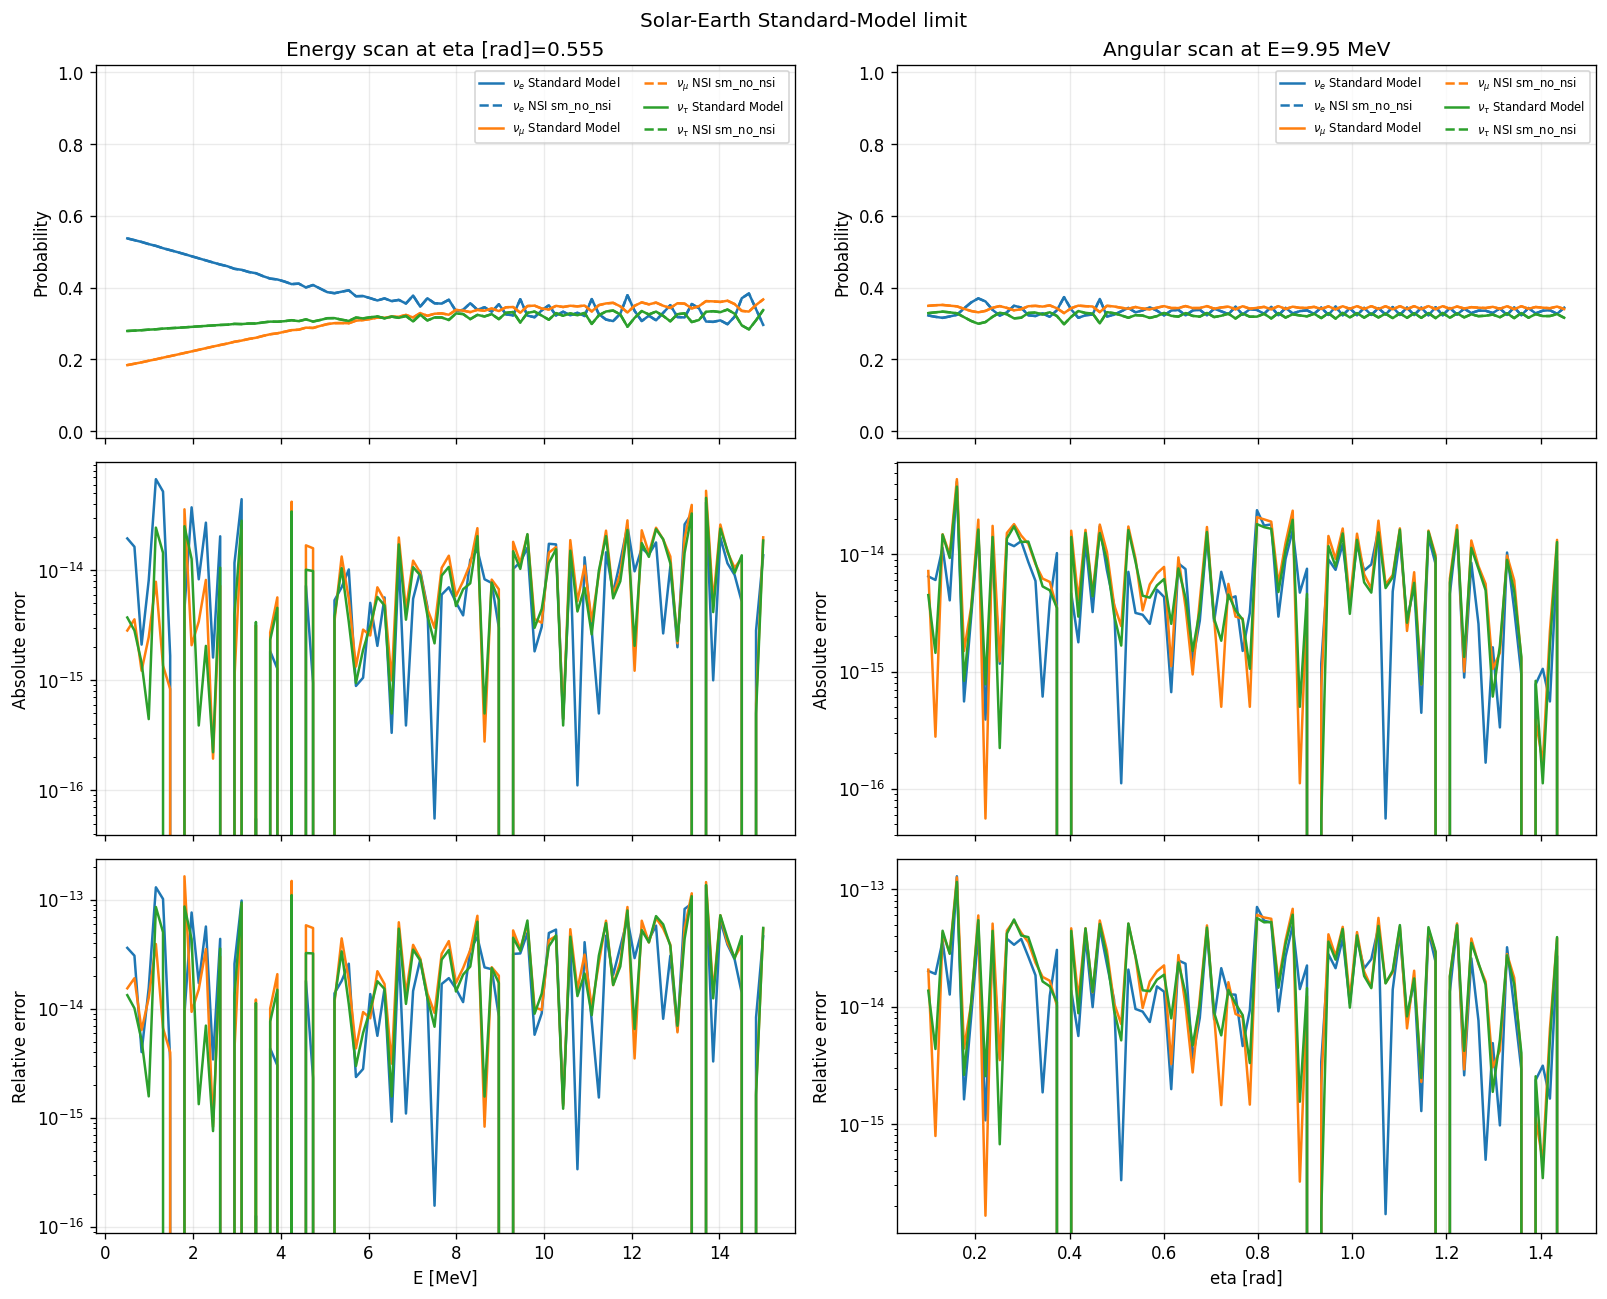

v:\output\validation\intrinsic\intrinsic2_nsi_fig3b_sm_limit_slices.png


In [5]:
oscillation_sm = PropagationConfig.oscillation_parameters_from_preset(OSCILLATION_PRESET, context=context, antinu=False)
oscillation_nsi_sm_limit = PropagationConfig.oscillation_parameters_from_preset(OSCILLATION_PRESET, context=context, antinu=False, NSI_extension='sm_no_nsi')
E_sm_limit = torch.linspace(0.5, 15.0, 90, device=context.device, dtype=context.dtype)
eta_sm_limit = torch.linspace(0.10, 1.45, 90, device=context.device, dtype=context.dtype)
sm_limit_weights_reference = solar_probability_mass(oscillation_sm, E_sm_limit, solar_medium, solar_source, '8B', method='adiabatic_exact', legacy_precision=LEGACY_PRECISION)
sm_limit_weights_tested = solar_probability_mass(oscillation_nsi_sm_limit, E_sm_limit, solar_medium, solar_source, '8B', method='adiabatic_exact', legacy_precision=LEGACY_PRECISION)
sm_limit_reference = solar_earth_sm_limit_grid(oscillation_sm, sm_limit_weights_reference)
sm_limit_tested = solar_earth_sm_limit_grid(oscillation_nsi_sm_limit, sm_limit_weights_tested)
sm_limit_row, sm_limit_abs, sm_limit_rel = validation_metrics('solar-Earth SM limit', sm_limit_reference, sm_limit_tested, reference_label='Standard Model', tested_label='NSI sm_no_nsi', absolute_threshold=ABSOLUTE_THRESHOLD)
display(pd.DataFrame([sm_limit_row]).set_index('case').style.format('{:.3e}'))
validation_heatmap(sm_limit_abs.amax(dim=-1), sm_limit_rel.amax(dim=-1), E_sm_limit, eta_sm_limit, title='Solar-Earth NSI Standard-Model limit', xlabel='E [MeV]', ylabel='nadir angle eta [rad]', filename='intrinsic2_nsi_fig3_sm_limit.png', output_dir=OUTPUT_DIR, reference_label='Standard Model', show_plots=config.show_plots)
validation_comparison_grid(sm_limit_reference, sm_limit_tested, E_sm_limit, eta_sm_limit, 0.55, 10.0, title='Solar-Earth Standard-Model limit', angle_label='eta [rad]', filename='intrinsic2_nsi_fig3b_sm_limit_slices.png', output_dir=OUTPUT_DIR, reference_label='Standard Model', tested_label='NSI sm_no_nsi', show_plots=config.show_plots)


## 4. Solar Propagation

This comparison evaluates the mass-eigenstate probabilities at the solar surface for $^8$B neutrinos using the two methods that support NSI:

- `numerical` coherently propagates the production state through the discretized solar profile and projects it onto the vacuum mass basis; it is the reference.
- `adiabatic_exact` diagonalizes the complete local flavour-basis Hamiltonian, including the Hermitian NSI matter matrix, at every production point while assuming adiabatic following.

After averaging over the normalized radial production distribution,

$$
P_i^{\odot,\mathrm{ad}}(E)=\int_0^{R_\odot}dr\,f_{8B}(r)\,|U^m_{ei}(r,E)|^2,
\qquad
\int_0^{R_\odot}dr\,f_{8B}(r)=1.
$$

The effective-angle method `adiabatic_approximated` is deliberately omitted because it is restricted to the Standard Model. Landau-Zener corrections are likewise unsupported for the NSI `adiabatic_exact` path.

**Expected results:**<br>
- `adiabatic_exact` should agree closely with the numerical reference where solar evolution is adiabatic.
- Differences measure the adiabatic approximation rather than a simplified NSI Hamiltonian.
- Both outputs must remain finite, non-negative and normalized.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_adiabatic_exact,relative_points,absolute_threshold
case,,,,,,,,
solar surface: adiabatic_exact vs numerical,1.550e-02,6.828e-04,2.289e-01,1.311e-02,8.512e-10,2.220e-16,3.600e+02,1.000e-03


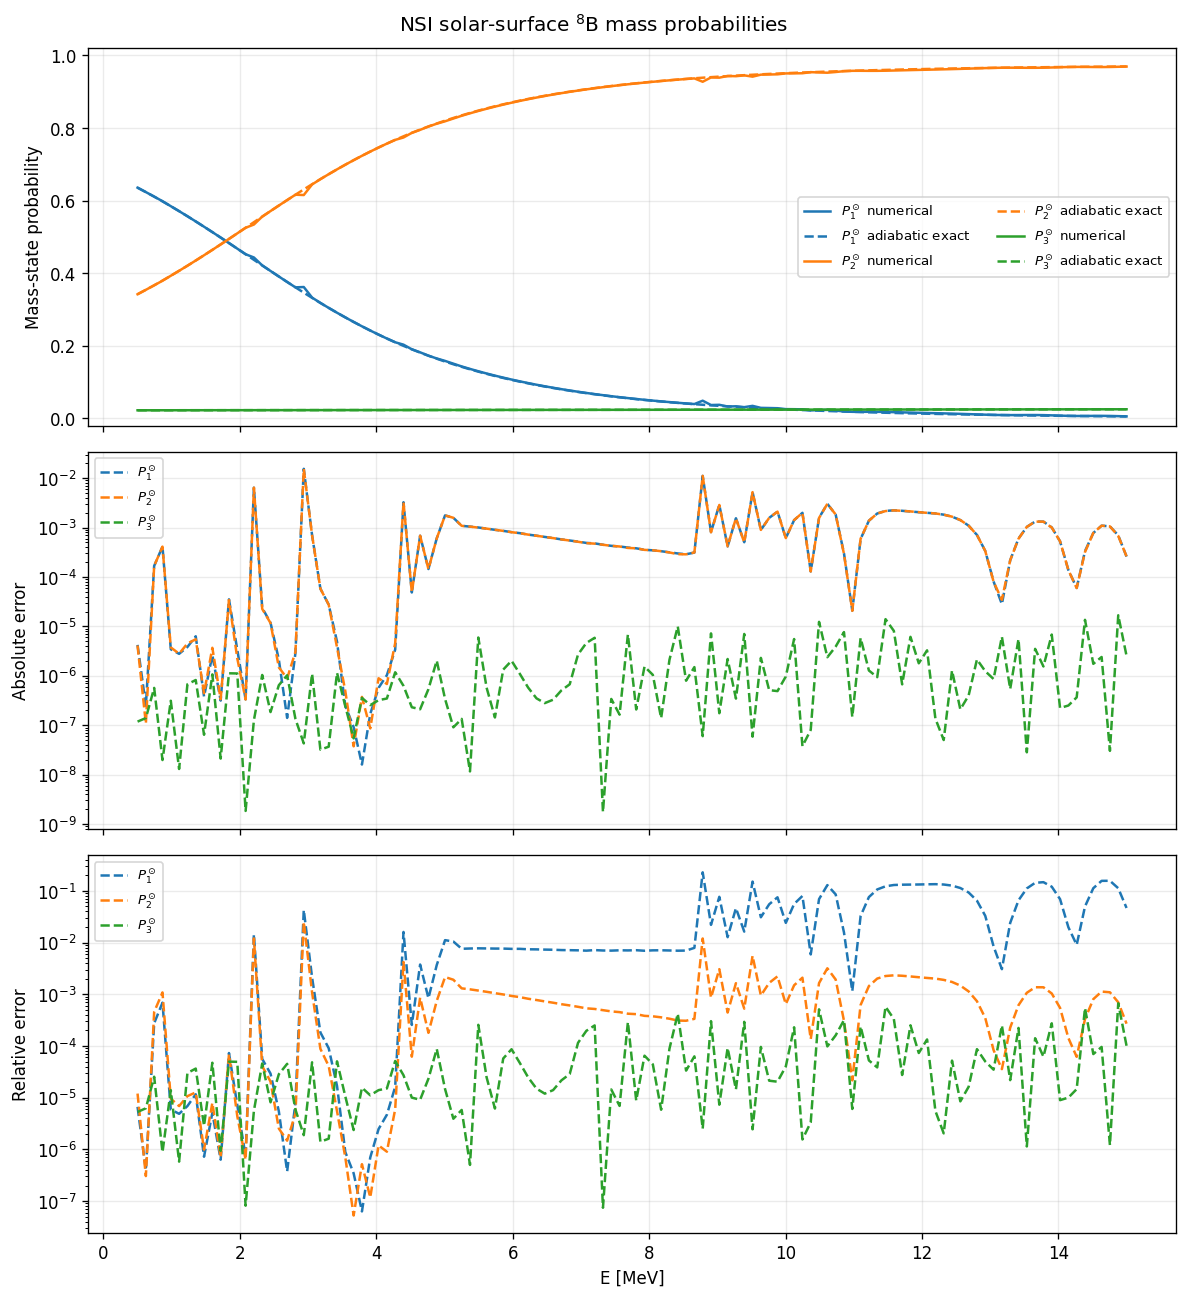

v:\output\validation\intrinsic\intrinsic2_nsi_fig4_solar_surface.png


In [6]:
E_solar_surface = torch.linspace(0.5, 15.0, 120, device=context.device, dtype=context.dtype)
solar_surface_reference = solar_probability_mass(oscillation, E_solar_surface, solar_medium, solar_source, '8B', method='numerical', numerical_sampling='midpoint', legacy_precision=LEGACY_PRECISION)
solar_surface_exact = solar_probability_mass(oscillation, E_solar_surface, solar_medium, solar_source, '8B', method='adiabatic_exact', legacy_precision=LEGACY_PRECISION)
solar_surface_row, solar_surface_abs, solar_surface_rel = validation_metrics('solar surface: adiabatic_exact vs numerical', solar_surface_reference, solar_surface_exact, reference_label='numerical', tested_label='adiabatic_exact', absolute_threshold=ABSOLUTE_THRESHOLD)
display(pd.DataFrame([solar_surface_row]).set_index('case').style.format('{:.3e}'))
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
for mass_index, colour in enumerate(('C0', 'C1', 'C2')):
    label = rf'$P_{{{mass_index + 1}}}^\odot$'
    axes[0].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_reference[:,mass_index]), color=colour, label=f'{label} numerical')
    axes[0].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_exact[:,mass_index]), '--', color=colour, label=f'{label} adiabatic exact')
    axes[1].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_abs[:,mass_index]), '--', color=colour, label=label)
    axes[2].plot(to_numpy(E_solar_surface), to_numpy(solar_surface_rel[:,mass_index]), '--', color=colour, label=label)
axes[0].set_ylabel('Mass-state probability'); axes[0].set_ylim(-0.02, 1.02); axes[0].legend(fontsize=8, ncol=2)
axes[1].set_ylabel('Absolute error'); axes[1].set_yscale('log'); axes[1].legend(fontsize=8)
axes[2].set_ylabel('Relative error'); axes[2].set_yscale('log'); axes[2].set_xlabel('E [MeV]'); axes[2].legend(fontsize=8)
for ax in axes: ax.grid(alpha=0.25)
fig.suptitle(r'NSI solar-surface $^8$B mass probabilities')
fig.tight_layout()
save_and_show('intrinsic2_nsi_fig4_solar_surface.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 5. Pure Flavour States Through Earth

The three coherent pure flavour states propagated independently are

$$|\nu_e\rangle=\begin{pmatrix}1\\0\\0\end{pmatrix},\qquad |\nu_\mu\rangle=\begin{pmatrix}0\\1\\0\end{pmatrix},\qquad |\nu_\tau\rangle=\begin{pmatrix}0\\0\\1\end{pmatrix}.$$

Each vector is propagated coherently through Earth over an energy-nadir grid, testing every initial-flavour column of the transition matrix. The numerical path uses 400 midpoint segments per trajectory. Parallel heatmaps show the maximum absolute and relative discrepancies over initial and final flavours. The additional $3\times2$ grid selects initial $\nu_e$: its left column scans energy near $\eta=0.60$ rad and its right column scans nadir angle near $E=5\,\mathrm{GeV}$. Both branches use `reunitarize=False`.

**Expected results:**<br>

- Both methods conserve total probability.
- The largest differences are expected for long core-crossing paths and around energies where the matter phase is most sensitive to the density approximation.
- The perturbative and numerical curves should follow the same physical oscillation pattern.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
pure flavour through Earth,2.770e-02,7.026e-04,5.648e-01,5.429e-03,1.967e-13,2.494e-02,71523,1.000e-03


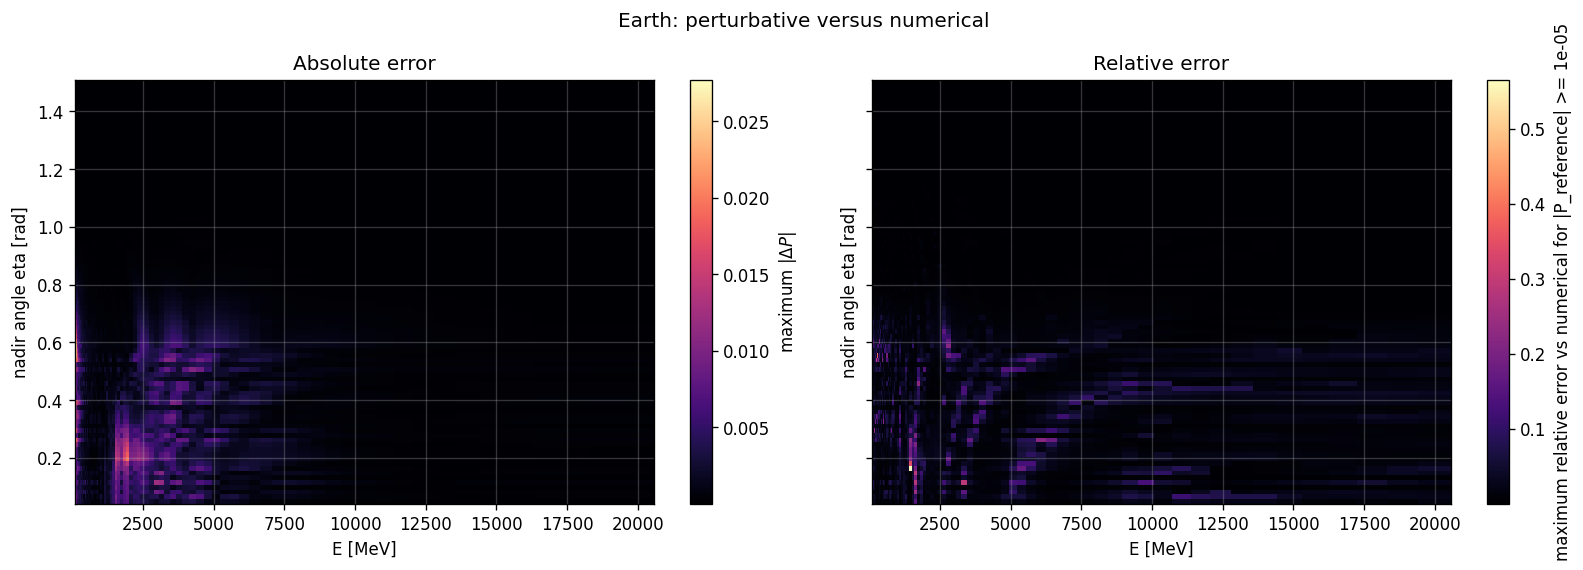

v:\output\validation\intrinsic\intrinsic2_nsi_fig5_earth.png


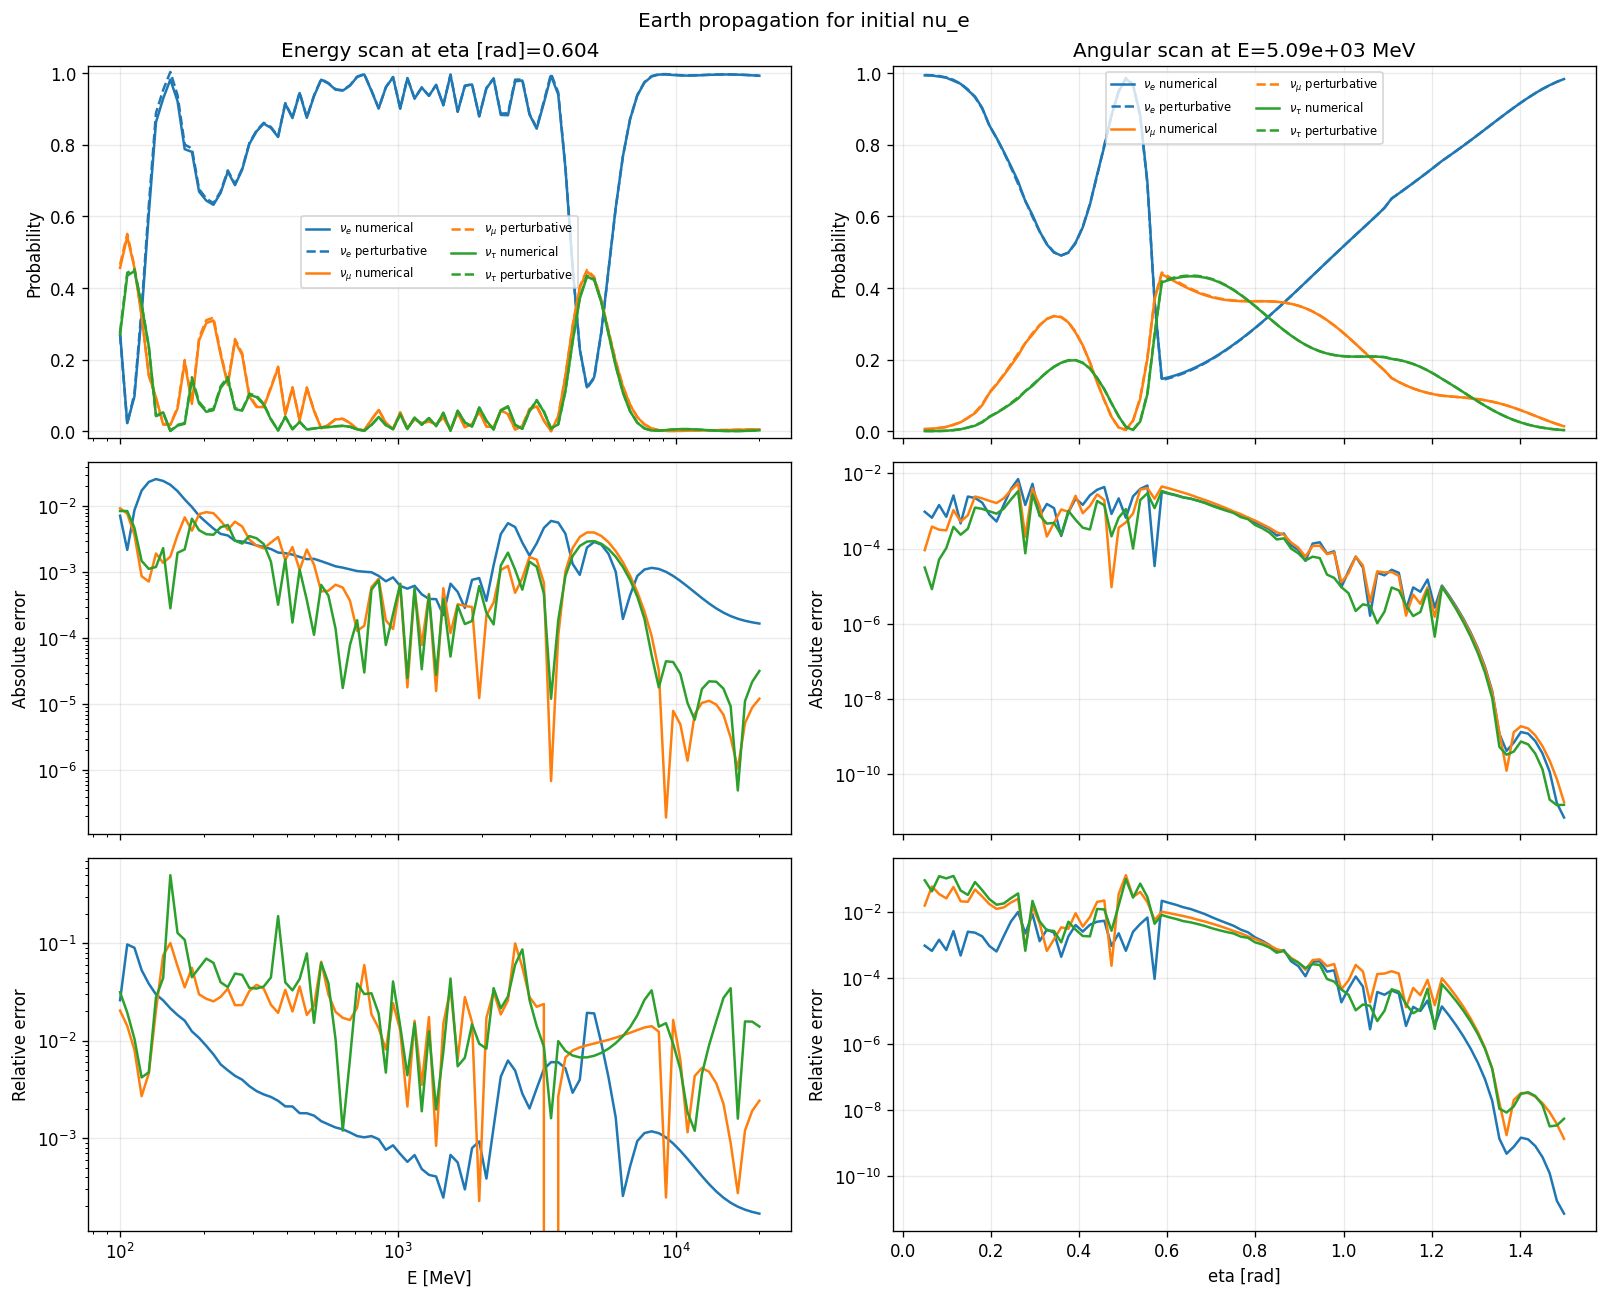

v:\output\validation\intrinsic\intrinsic2_nsi_fig5b_earth_slices.png


In [7]:
E_earth = torch.logspace(np.log10(100.0), np.log10(2.0e4), 90, device=context.device, dtype=context.dtype)
eta_earth = torch.linspace(0.05, 1.50, 90, device=context.device, dtype=context.dtype)
earth_reference = earth_flavour_grid('numerical')
earth_tested = earth_flavour_grid('analytical')
earth_abs, earth_rel = record_metrics('pure flavour through Earth', earth_reference, earth_tested)
validation_heatmap(earth_abs.amax(dim=(0,3)), earth_rel.amax(dim=(0,3)), E_earth, eta_earth, title='Earth: perturbative versus numerical', xlabel='E [MeV]', ylabel='nadir angle eta [rad]', filename='intrinsic2_nsi_fig5_earth.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(earth_reference[0], earth_tested[0], E_earth, eta_earth, 0.60, 5000.0, title='Earth propagation for initial nu_e', angle_label='eta [rad]', filename='intrinsic2_nsi_fig5b_earth_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, log_energy=True, show_plots=config.show_plots)


## 6. Solar Neutrinos to the Detector

Solar $^8$B neutrinos are produced as $\nu_e$ and converted by the NSI-compatible `adiabatic_exact` solar calculation into incoherent mass-eigenstate weights. These common weights are propagated through Earth to the detector; only the Earth method differs between the reference and tested branches. Parallel heatmaps display the maximum errors over final flavour, and the $3\times2$ grid compares the three detected flavours near $\eta=0.55$ rad and $E=10\,\mathrm{MeV}$. Both branches use `reunitarize=False`.

**Expected results:**<br>

- All final-flavour probabilities remain normalized.
- Day-night regeneration is strongest for trajectories with small nadir angle and long Earth chords.
- Perturbative-numerical discrepancies should remain small compared with the physical Earth matter effect.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
solar production to detector,1.030e-02,4.264e-04,3.412e-02,1.295e-03,1.899e-11,8.050e-04,24300,1.000e-03


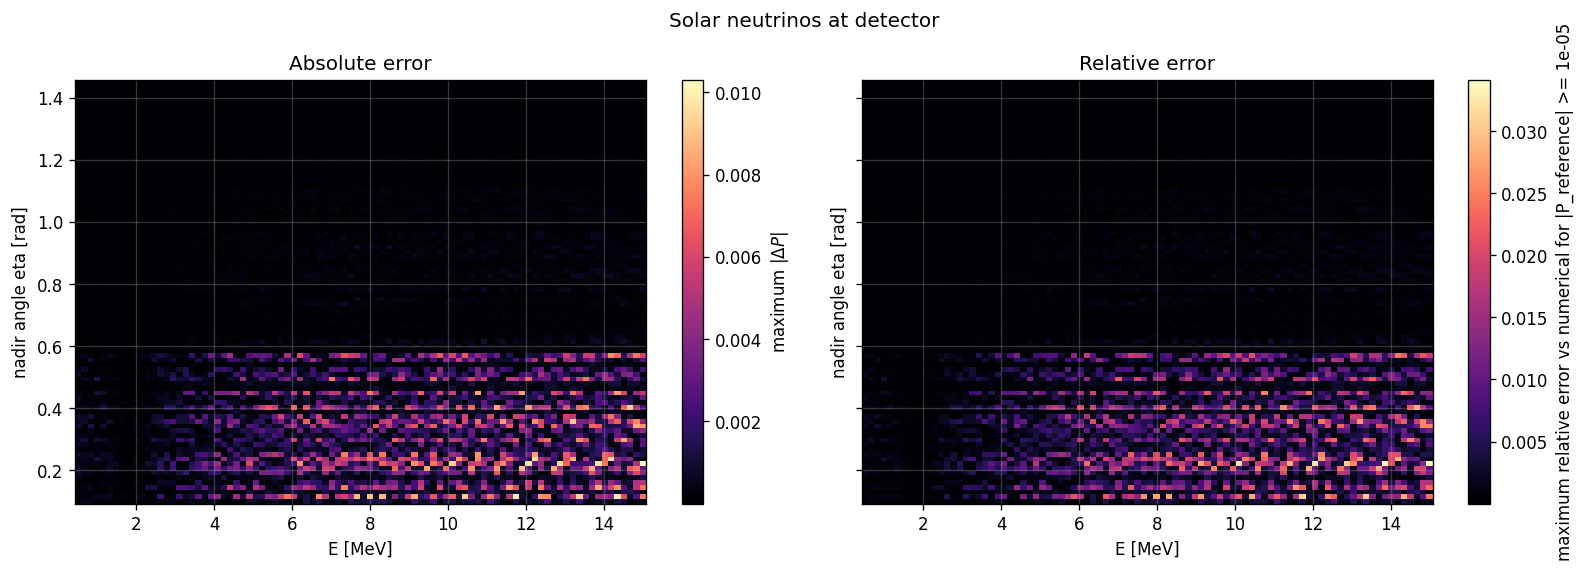

v:\output\validation\intrinsic\intrinsic2_nsi_fig6_solar.png


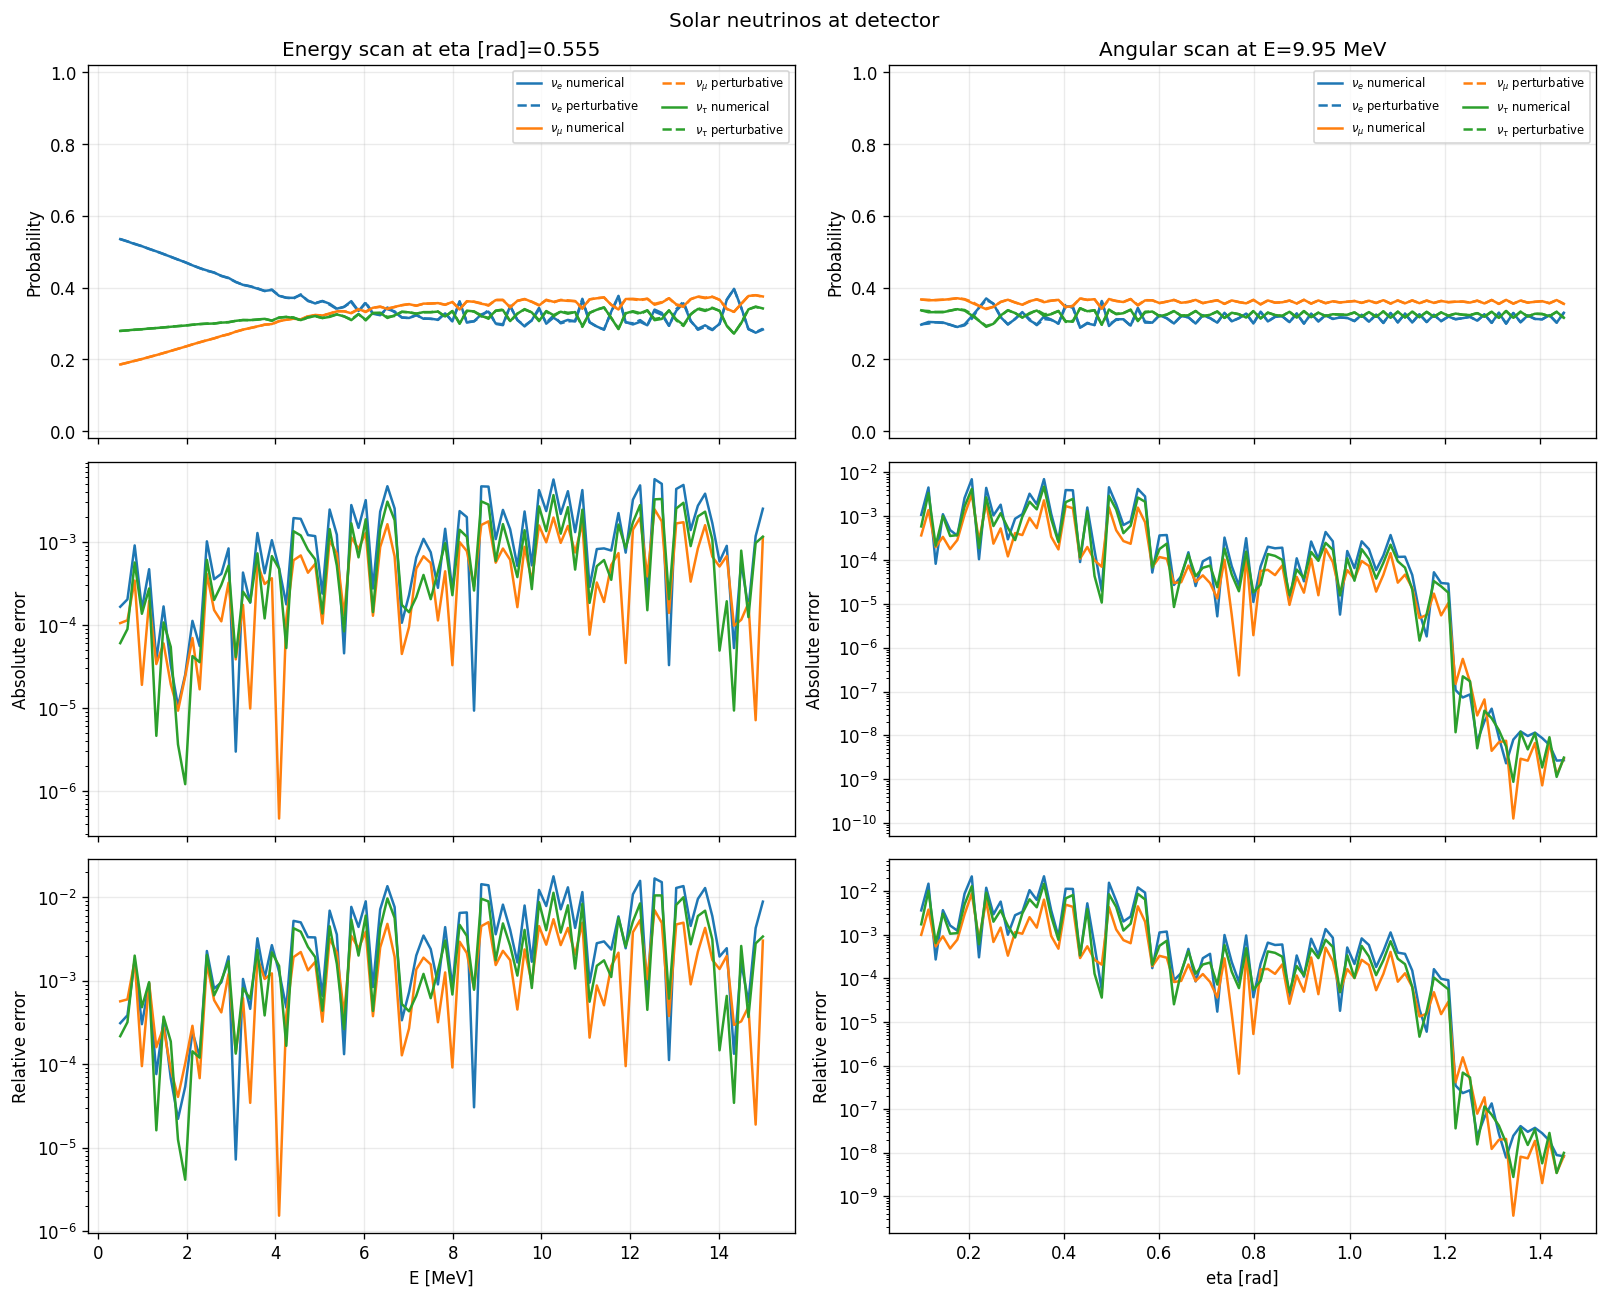

v:\output\validation\intrinsic\intrinsic2_nsi_fig6b_solar_slices.png


In [8]:
E_solar = torch.linspace(0.5, 15.0, 90, device=context.device, dtype=context.dtype)
eta_solar = torch.linspace(0.10, 1.45, 90, device=context.device, dtype=context.dtype)
solar_weights = solar_probability_mass(oscillation, E_solar, solar_medium, solar_source, '8B', method='adiabatic_exact', legacy_precision=LEGACY_PRECISION)
solar_reference = solar_detector_grid('numerical')
solar_tested = solar_detector_grid('analytical')
solar_abs, solar_rel = record_metrics('solar production to detector', solar_reference, solar_tested)
validation_heatmap(solar_abs.amax(dim=-1), solar_rel.amax(dim=-1), E_solar, eta_solar, title='Solar neutrinos at detector', xlabel='E [MeV]', ylabel='nadir angle eta [rad]', filename='intrinsic2_nsi_fig6_solar.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(solar_reference, solar_tested, E_solar, eta_solar, 0.55, 10.0, title='Solar neutrinos at detector', angle_label='eta [rad]', filename='intrinsic2_nsi_fig6b_solar_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, show_plots=config.show_plots)


## 7. Atmospheric Propagation


### 7.1 Atmospheric neutrinos to the surface

The complete coherent $3\times3$ flavour-transition matrix is compared at the Earth surface. The perturbative atmosphere uses six cubic local fits and the numerical reference uses 600 midpoint density segments. Both plotted errors are maximized over the complete transition matrix. The $3\times2$ grid selects initial $\nu_e$ and shows energy dependence near the horizon ($\theta=89^\circ$) and angular dependence near $E=10\,\mathrm{GeV}$.

**Expected results:**<br>

- Agreement should be especially strong because atmospheric electron density is low.
- Differences may grow near the horizon, where the atmospheric path is longest.
- Every transition-matrix column should sum to one.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
atmosphere production to surface,1.651e-11,2.198e-13,1.551e-09,1.616e-11,4.965e-13,6.828e-14,43874,1.000e-03


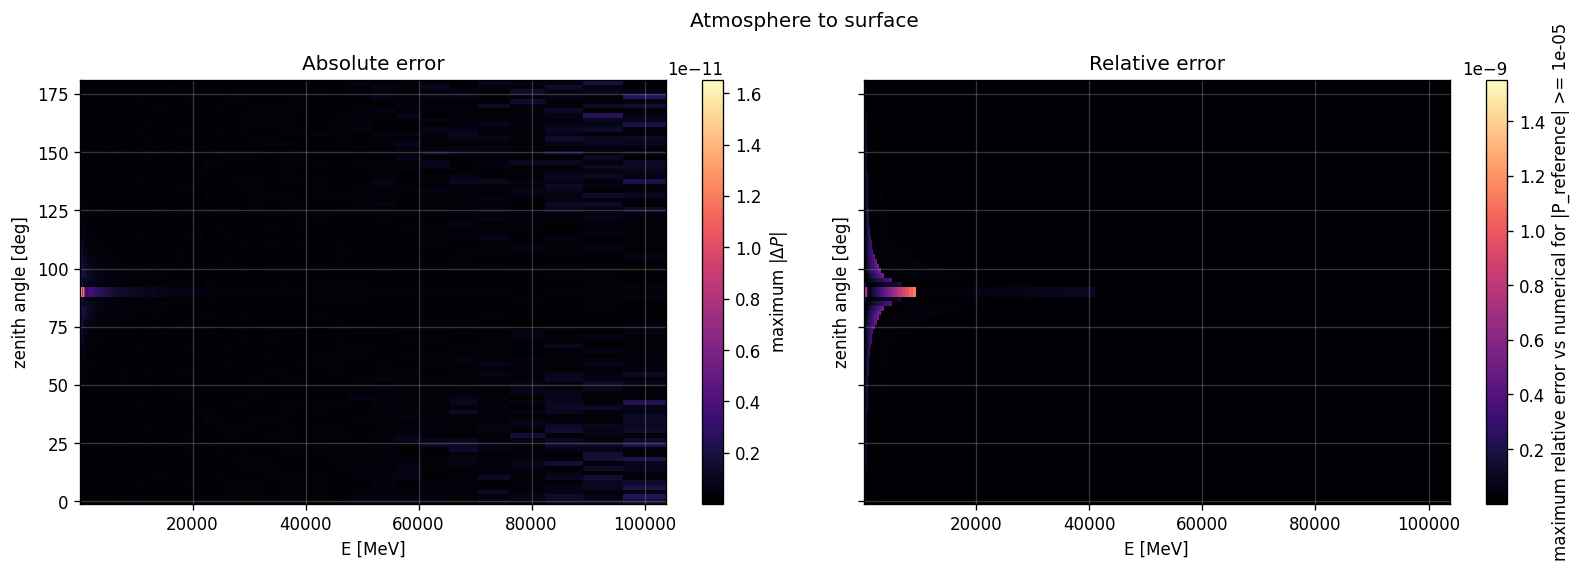

v:\output\validation\intrinsic\intrinsic2_nsi_fig71_surface.png


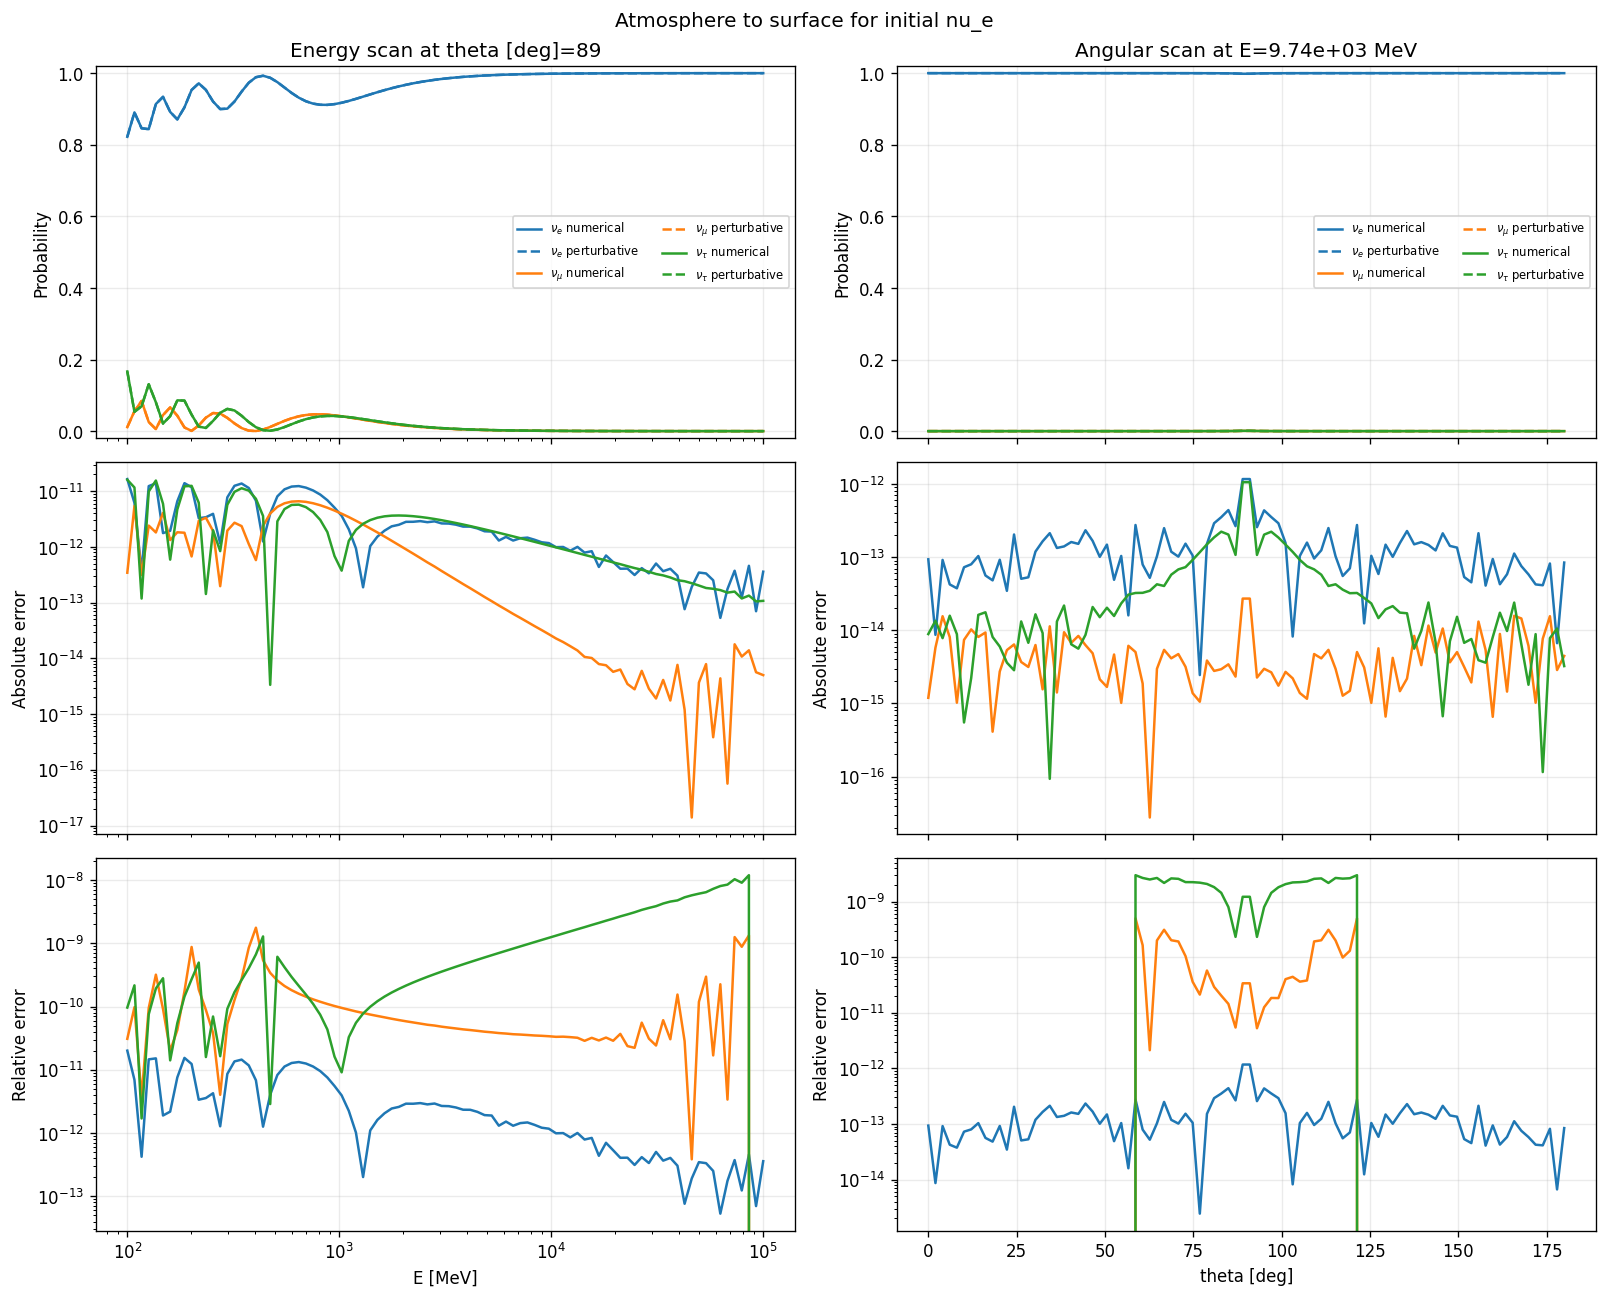

v:\output\validation\intrinsic\intrinsic2_nsi_fig71b_surface_slices.png


In [9]:
E_atm = torch.logspace(2.0, 5.0, 90, device=context.device, dtype=context.dtype)
theta_atm = torch.linspace(0.0, 180.0, 90, device=context.device, dtype=context.dtype)
atm_args = dict(oscillation=oscillation, E_MeV=E_atm[:,None], h_km=25.0, theta_deg=theta_atm[None,:], depth_km=DEPTH_M/1000.0, atmosphere=atmosphere, context=context, legacy_precision=LEGACY_PRECISION)
surface_reference = atmosphere_probability_transition(**atm_args, method='numerical')
surface_tested = atmosphere_probability_transition(**atm_args, method='analytical')
surface_abs, surface_rel = record_metrics('atmosphere production to surface', surface_reference, surface_tested)
validation_heatmap(surface_abs.amax(dim=(-2,-1)), surface_rel.amax(dim=(-2,-1)), E_atm, theta_atm, title='Atmosphere to surface', xlabel='E [MeV]', ylabel='zenith angle [deg]', filename='intrinsic2_nsi_fig71_surface.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(surface_reference[..., :,0], surface_tested[..., :,0], E_atm, theta_atm, 89.0, 1e4, title='Atmosphere to surface for initial nu_e', angle_label='theta [deg]', filename='intrinsic2_nsi_fig71b_surface_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, log_energy=True, show_plots=config.show_plots)


### 7.2 Atmospheric neutrinos to the underground detector

Atmosphere amplitudes act on each pure state first; the resulting coherent surface state is then propagated through Earth. The total probability is therefore not constructed by multiplying probability matrices. Parallel heatmaps summarize the maximum errors. The $3\times2$ grid selects initial $\nu_e$, an up-going trajectory at $\theta=150^\circ$, and an angular scan near $E=5\,\mathrm{GeV}$. Both basic branches use `reunitarize=False`.

**Expected results:**<br>

- Down-going events mainly test atmospheric propagation, whereas up-going events also test long Earth chords.
- Combined probabilities must remain normalized.
- The largest discrepancies are expected for up-going, matter-sensitive trajectories; this is the strongest end-to-end test because coherence is retained at the surface.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
atmosphere production to detector,2.825e-02,3.916e-04,6.381e-01,3.425e-03,6.830e-13,2.494e-02,63005,1.000e-03


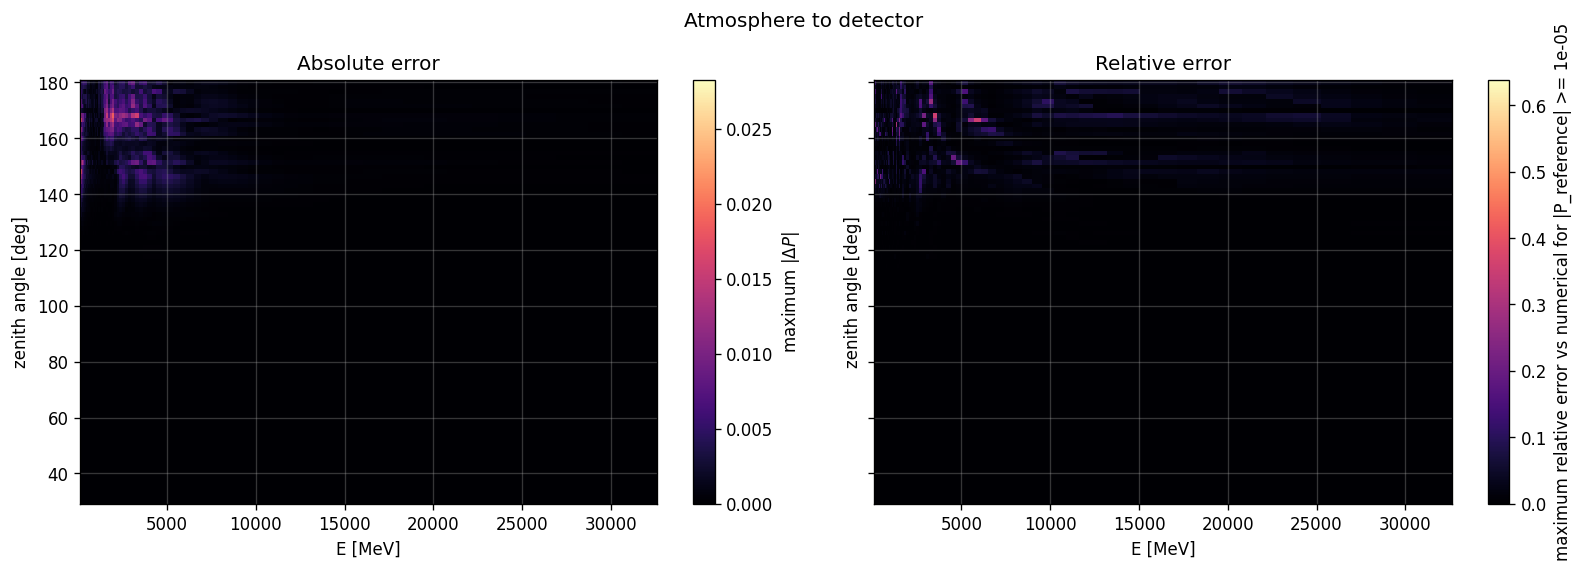

v:\output\validation\intrinsic\intrinsic2_nsi_fig72_detector.png


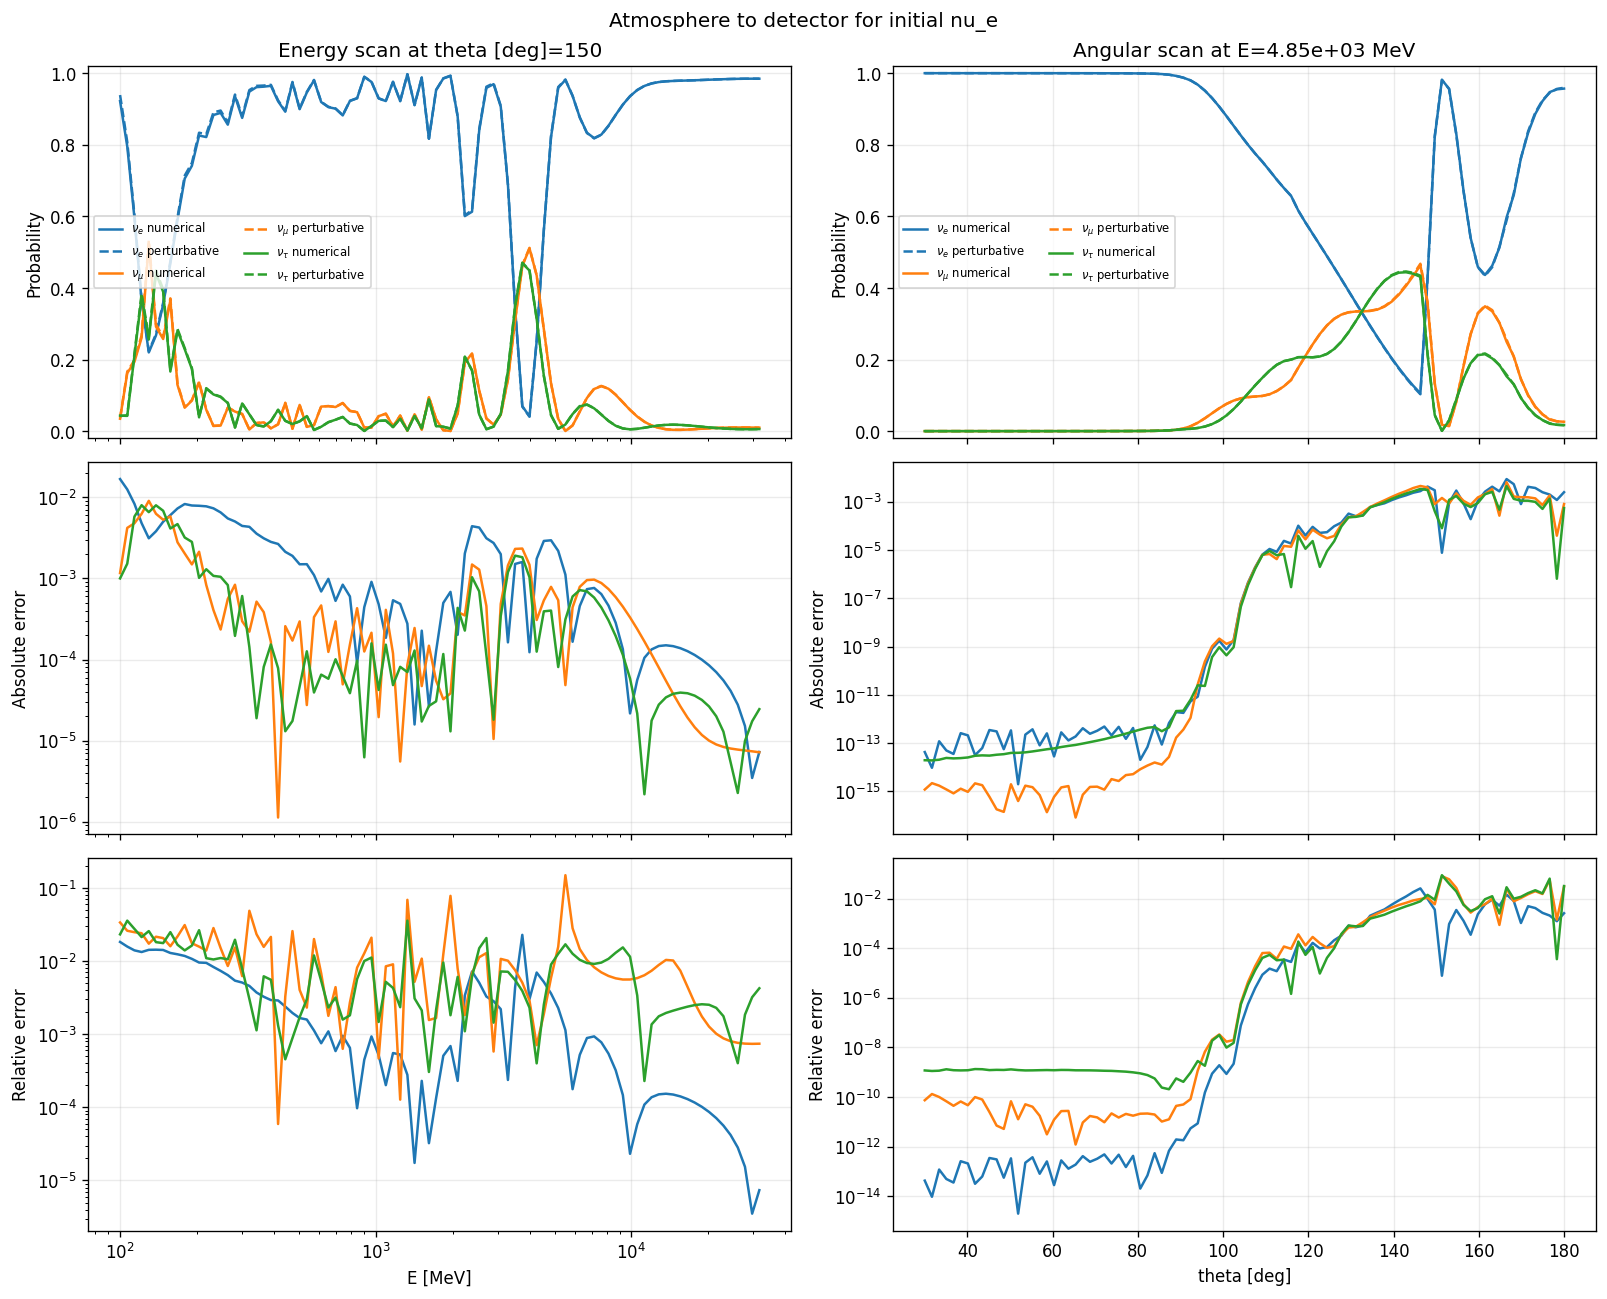

v:\output\validation\intrinsic\intrinsic2_nsi_fig72b_detector_slices.png


In [10]:
E_det = torch.logspace(2.0, 4.5, 90, device=context.device, dtype=context.dtype)
theta_det = torch.linspace(30.0, 180.0, 90, device=context.device, dtype=context.dtype)
detector_reference = atmosphere_detector_grid('numerical')
detector_tested = atmosphere_detector_grid('analytical')
detector_abs, detector_rel = record_metrics('atmosphere production to detector', detector_reference, detector_tested)
validation_heatmap(detector_abs.amax(dim=(0,3)), detector_rel.amax(dim=(0,3)), E_det, theta_det, title='Atmosphere to detector', xlabel='E [MeV]', ylabel='zenith angle [deg]', filename='intrinsic2_nsi_fig72_detector.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, show_plots=config.show_plots)
validation_comparison_grid(detector_reference[0], detector_tested[0], E_det, theta_det, 150.0, 5000.0, title='Atmosphere to detector for initial nu_e', angle_label='theta [deg]', filename='intrinsic2_nsi_fig72b_detector_slices.png', output_dir=OUTPUT_DIR, reference_label=REFERENCE_LABEL, tested_label=TESTED_LABEL, log_energy=True, show_plots=config.show_plots)


## 8. Summary
The summary contains the four end-to-end physical comparisons accumulated in this notebook: pure-flavour Earth propagation, solar neutrinos at the detector, atmospheric propagation to the surface and atmosphere-plus-Earth propagation to the underground detector. Solar-surface and Standard-Model-limit diagnostics remain separate because they compare different approximations or physical models.

The table and $2\times2$ chart report maximum and mean absolute and thresholded-relative errors. Probability-normalization diagnostics remain available in the table.

**Expected results:**<br>
- Every metric must be finite.
- Normalization errors must remain small
- The numerical and tested methods must reproduce the same NSI oscillation patterns.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical,normalization_perturbative,relative_points,absolute_threshold
case,,,,,,,,
pure flavour through Earth,2.770e-02,7.026e-04,5.648e-01,5.429e-03,1.967e-13,2.494e-02,7.152e+04,1.000e-03
solar production to detector,1.030e-02,4.264e-04,3.412e-02,1.295e-03,1.899e-11,8.050e-04,2.430e+04,1.000e-03
atmosphere production to surface,1.651e-11,2.198e-13,1.551e-09,1.616e-11,4.965e-13,6.828e-14,4.387e+04,1.000e-03
atmosphere production to detector,2.825e-02,3.916e-04,6.381e-01,3.425e-03,6.830e-13,2.494e-02,6.300e+04,1.000e-03


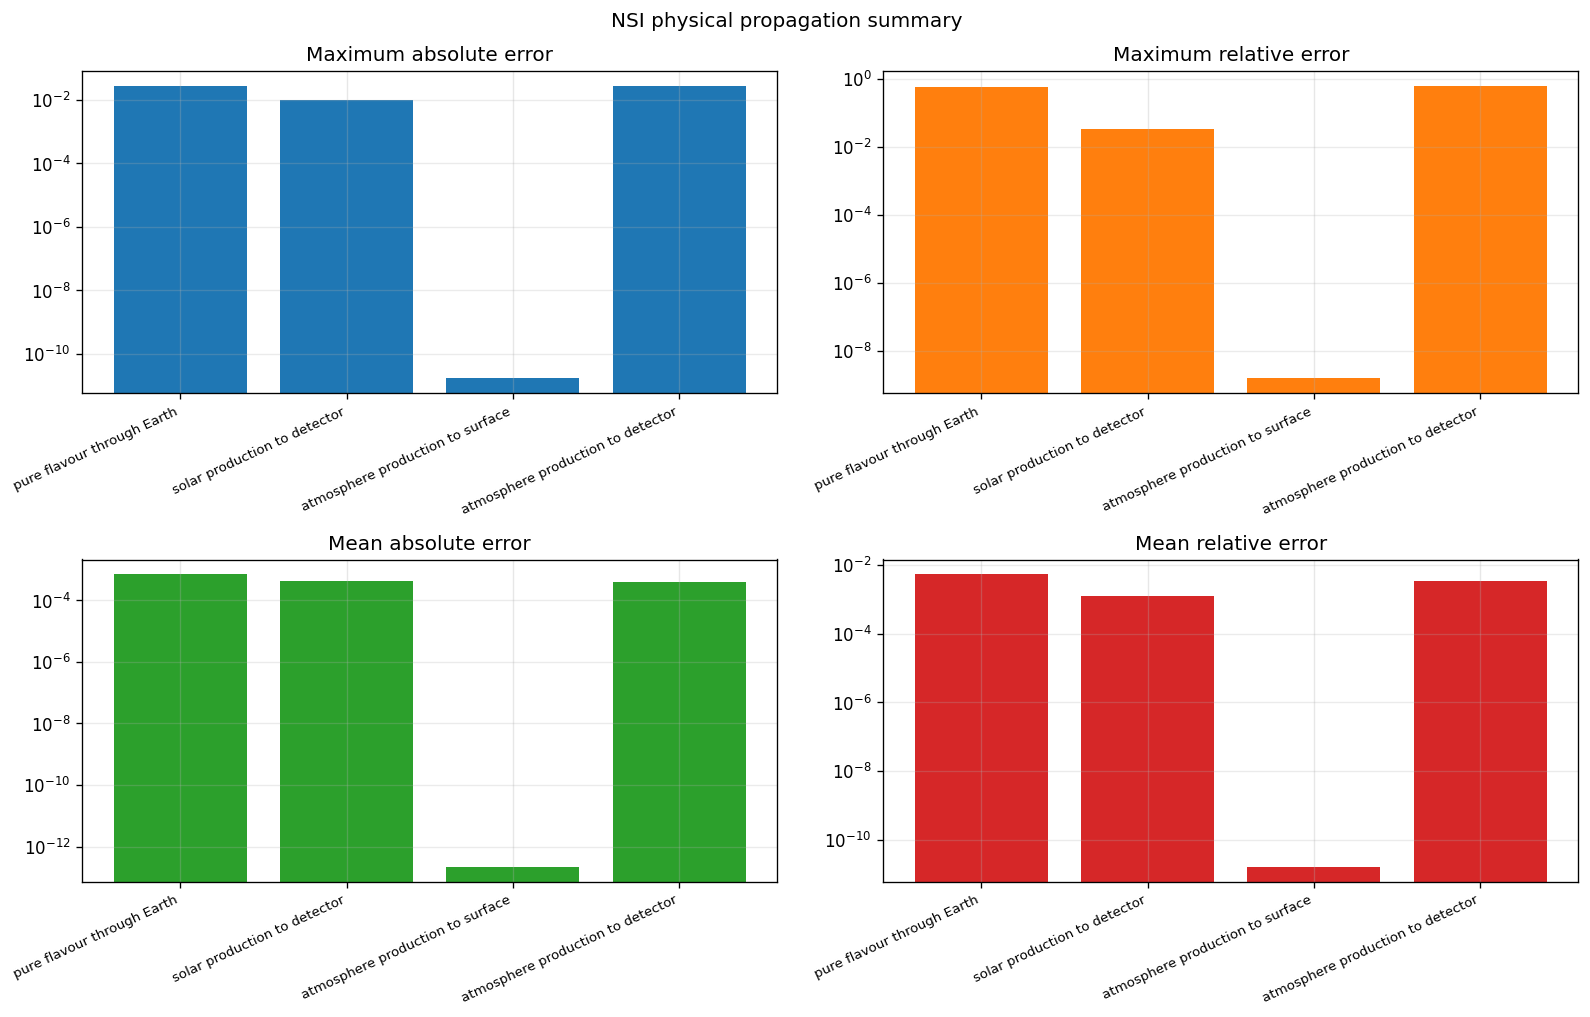

v:\output\validation\intrinsic\intrinsic2_nsi_fig8_summary.png
All four physical comparisons completed successfully.


In [11]:
summary = pd.DataFrame(summaries).set_index('case')
display(summary.style.format({column: '{:.3e}' for column in summary.select_dtypes(include='number').columns}))
summary.to_csv(OUTPUT_DIR / 'validation_intrinsic2_nsi_summary.csv')
validation_summary_plot(summaries, title='NSI physical propagation summary', filename='intrinsic2_nsi_fig8_summary.png', output_dir=OUTPUT_DIR, show_plots=config.show_plots)
assert np.isfinite(summary[['max_abs','mean_abs','max_rel','mean_rel']].to_numpy()).all()
print('All four physical comparisons completed successfully.')
